# Demo Video
**Video URL:** https://YOUR_VIDEO_URL_HERE


**Student:** Kenneth Flynn Gunawan | **NIM:** 2802413871

## 1. Imports & Setup

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.linear_model import LogisticRegression, LinearRegression
from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor
from sklearn.neighbors import KNeighborsClassifier, KNeighborsRegressor
from sklearn.tree import DecisionTreeClassifier, DecisionTreeRegressor
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from xgboost import XGBClassifier, XGBRegressor
from sklearn.metrics import (
    classification_report, f1_score, confusion_matrix,
    mean_squared_error, r2_score, mean_absolute_error
)

import warnings
warnings.filterwarnings('ignore', category=FutureWarning)
warnings.filterwarnings('ignore', category=UserWarning)
sns.set_theme(style='whitegrid')

## 2. Data Loading
Features and targets come in separate files: `A.csv` and `A_targets.csv`. We join them on Student_ID, then drop that column since it's just a row identifier.

In [3]:
features = pd.read_csv('A.csv')
targets  = pd.read_csv('A_targets.csv')

df = features.merge(targets, on='Student_ID')
df.drop(columns=['Student_ID'], inplace=True)

print('Shape:', df.shape)
df.head()

Shape: (5000, 24)


,gender,branch,cgpa,tenth_percentage,twelfth_percentage,backlogs,study_hours_per_day,attendance_percentage,projects_completed,internships_completed,...,certifications_count,sleep_hours,stress_level,part_time_job,family_income_level,city_tier,internet_access,extracurricular_involvement,placement_status,salary_lpa
0,Male,ECE,8.74,74.0,75.0,0,3.8,71.1,7,3,...,5,6.5,8,Yes,Medium,Tier 2,Yes,Medium,Placed,14.95
1,Female,ECE,7.80,75.3,69.7,0,6.3,69.5,5,1,...,1,7.1,8,Yes,Medium,Tier 3,Yes,Low,Placed,14.91
2,Female,IT,6.95,62.8,68.3,0,1.5,62.5,8,2,...,3,6.1,2,No,Low,Tier 2,Yes,High,Placed,17.73
3,Male,ECE,7.46,57.9,51.4,1,4.7,64.6,6,2,...,2,7.3,7,No,Medium,Tier 1,Yes,Low,Placed,14.52
4,Male,IT,6.86,61.3,73.5,2,5.2,75.9,3,3,...,1,6.0,7,No,Medium,Tier 1,Yes,Medium,Placed,15.91


## 3. Exploratory Data Analysis
### 3.1 Data Types & Basic Info

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 24 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   gender                       5000 non-null   object 
 1   branch                       5000 non-null   object 
 2   cgpa                         5000 non-null   float64
 3   tenth_percentage             5000 non-null   float64
 4   twelfth_percentage           5000 non-null   float64
 5   backlogs                     5000 non-null   int64  
 6   study_hours_per_day          5000 non-null   float64
 7   attendance_percentage        5000 non-null   float64
 8   projects_completed           5000 non-null   int64  
 9   internships_completed        5000 non-null   int64  
 10  coding_skill_rating          5000 non-null   int64  
 11  communication_skill_rating   5000 non-null   int64  
 12  aptitude_skill_rating        5000 non-null   int64  
 13  hackathons_partici

In [5]:
df.describe()

,cgpa,tenth_percentage,twelfth_percentage,backlogs,study_hours_per_day,attendance_percentage,projects_completed,internships_completed,coding_skill_rating,communication_skill_rating,aptitude_skill_rating,hackathons_participated,certifications_count,sleep_hours,stress_level,salary_lpa
count,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000
mean,8.283798,74.537400,74.543060,0.343600,4.041120,72.041560,5.529400,2.132600,3.728600,3.025400,4.116400,3.704200,2.836000,6.955000,6.020200,13.897180
std,1.008391,10.266752,10.244481,0.612547,1.967754,7.720029,2.053772,1.143713,1.278464,1.412358,0.716208,1.603252,1.781724,1.147881,2.851213,6.247481
min,5.000000,50.000000,50.000000,0.000000,0.000000,44.700000,0.000000,0.000000,1.000000,1.000000,1.000000,0.000000,0.000000,4.000000,1.000000,0.000000
25%,7.610000,67.400000,67.600000,0.000000,2.700000,66.600000,4.000000,1.000000,3.000000,2.000000,4.000000,3.000000,2.000000,6.200000,4.000000,12.510000
50%,8.320000,74.700000,74.800000,0.000000,4.000000,72.050000,6.000000,2.000000,4.000000,3.000000,4.000000,4.000000,3.000000,7.000000,6.000000,15.760000
75%,9.020000,82.000000,81.700000,1.000000,5.400000,77.200000,7.000000,3.000000,5.000000,4.000000,5.000000,5.000000,4.000000,7.800000,9.000000,18.332500
max,10.000000,100.000000,100.000000,5.000000,10.000000,99.200000,8.000000,4.000000,5.000000,5.000000,5.000000,6.000000,9.000000,9.000000,10.000000,20.000000


### 3.2 Missing Values
`extracurricular_involvement` is the only column with missing data, about 1006 rows (20%). The three categories are roughly balanced, so we fill with the mode ('Medium'). Dropping those rows would throw away a fifth of the dataset for no real gain.

In [6]:
print('Missing values per column:')
print(df.isnull().sum()[df.isnull().sum() > 0])

Missing values per column:
extracurricular_involvement    1006
dtype: int64


In [7]:
mode_val = df['extracurricular_involvement'].mode()[0]
df['extracurricular_involvement'] = df['extracurricular_involvement'].fillna(mode_val)
print(f'Imputed missing values with mode: "{mode_val}"')
print('Missing values after imputation:', df.isnull().sum().sum())

Imputed missing values with mode: "Medium"
Missing values after imputation: 0


### 3.3 Target Variable Analysis
`placement_status`  is heavily skewed: roughly 86% Placed, 14% Not Placed. A model that always predicts "Placed" would still score 86% accuracy, so accuracy is the wrong metric here. We use weighted F1 instead.

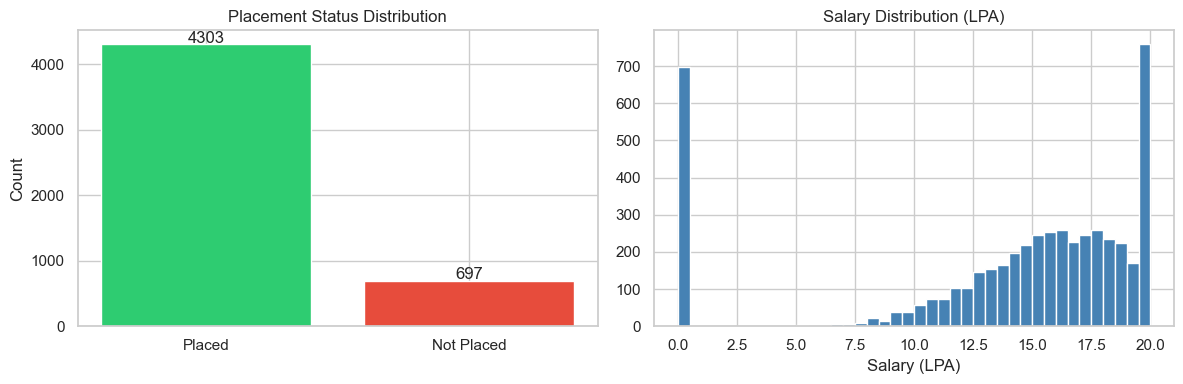

Placement counts:
 placement_status
Placed        4303
Not Placed     697
Name: count, dtype: int64


In [8]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Classification target
counts = df['placement_status'].value_counts()
axes[0].bar(counts.index, counts.values, color=['#2ecc71', '#e74c3c'])
axes[0].set_title('Placement Status Distribution')
axes[0].set_ylabel('Count')
for i, v in enumerate(counts.values):
    axes[0].text(i, v + 30, str(v), ha='center')

# Regression target
df['salary_lpa'].hist(ax=axes[1], bins=40, color='steelblue', edgecolor='white')
axes[1].set_title('Salary Distribution (LPA)')
axes[1].set_xlabel('Salary (LPA)')

plt.tight_layout()
plt.show()
print('Placement counts:\n', counts)

### 3.4 Feature Distributions

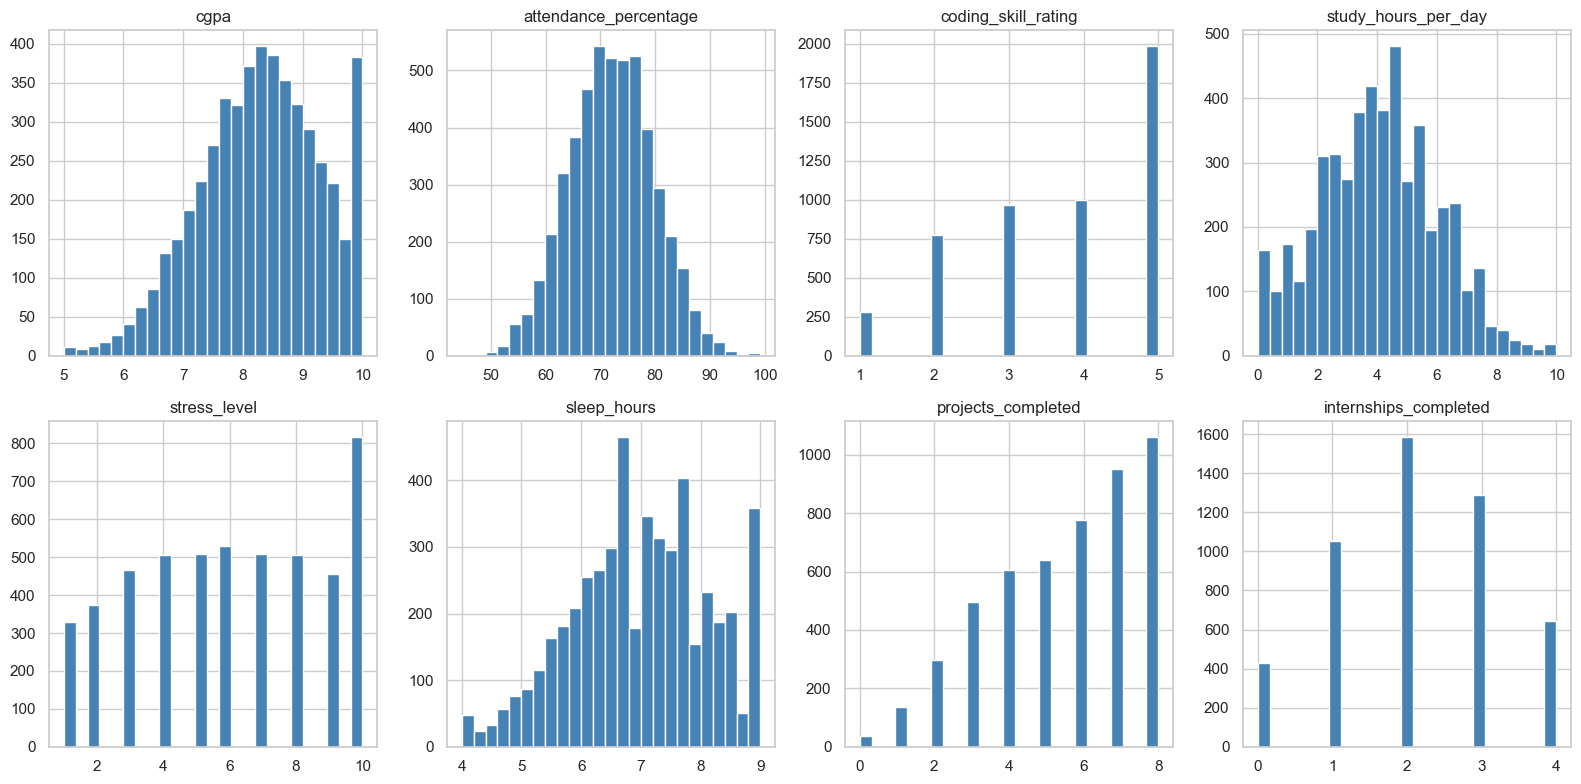

In [9]:
num_cols = ['cgpa', 'attendance_percentage', 'coding_skill_rating',
            'study_hours_per_day', 'stress_level', 'sleep_hours',
            'projects_completed', 'internships_completed']

fig, axes = plt.subplots(2, 4, figsize=(16, 8))
for ax, col in zip(axes.flatten(), num_cols):
    df[col].hist(ax=ax, bins=25, color='steelblue', edgecolor='white')
    ax.set_title(col)
plt.tight_layout()
plt.show()

### 3.5 Correlation Heatmap
`CGPA`, `coding_skill_rating`, and `aptitude_skill_rating` show the strongest positive correlations with salary. backlogs goes the other direction. Students with more backlogs are less likely to be placed and tend to earn lower salaries.

Text(0.5, 1.0, 'Correlation Heatmap')

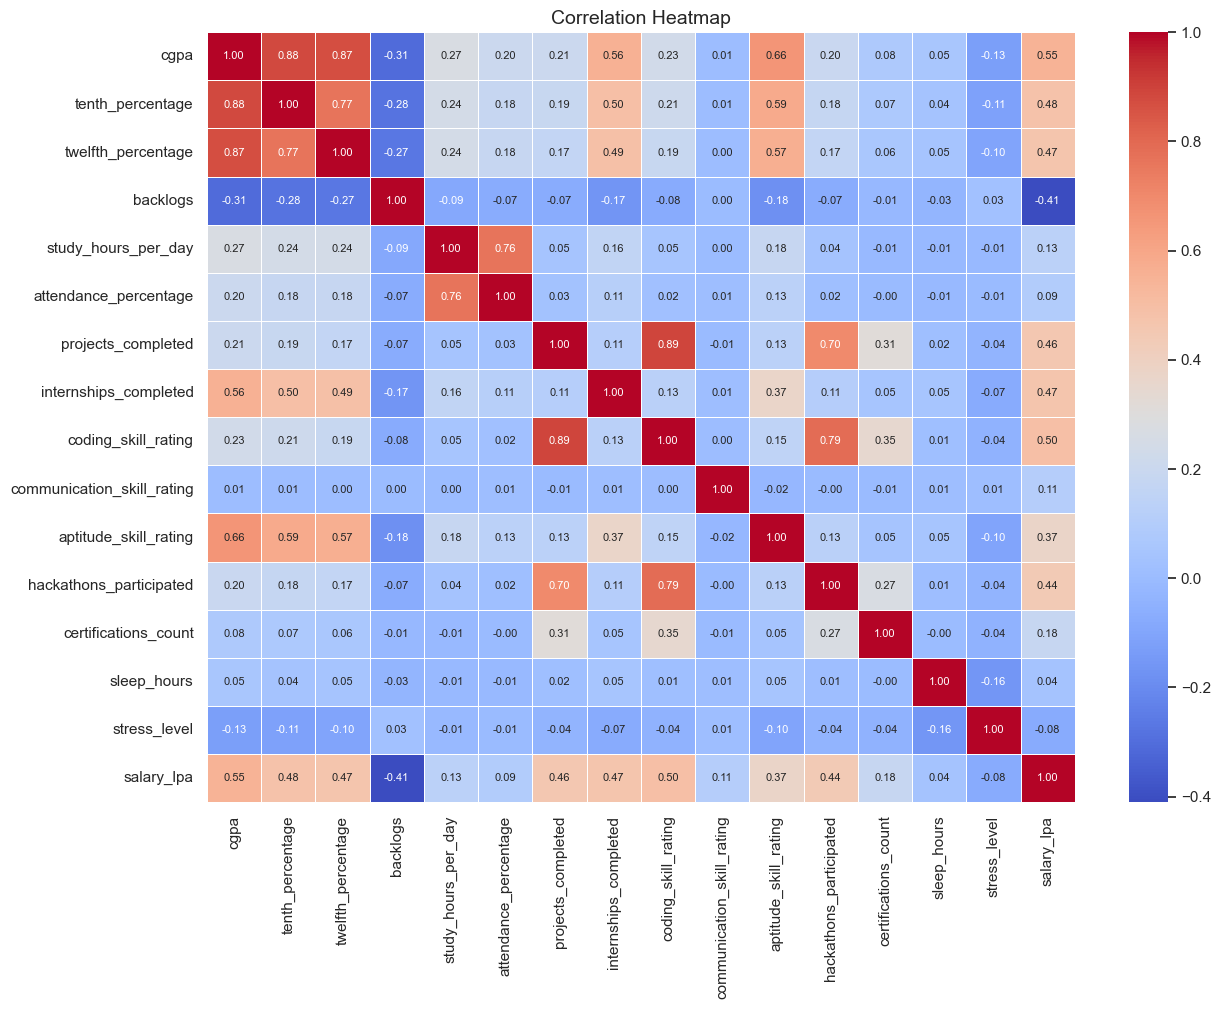

In [10]:
numeric_df = df.select_dtypes(include='number')
plt.figure(figsize=(14, 10))
sns.heatmap(numeric_df.corr(), annot=True, fmt='.2f', cmap='coolwarm',
            linewidths=0.5, annot_kws={'size': 8})
plt.title('Correlation Heatmap', fontsize=14)

### 3.6 Categorical Feature Analysis

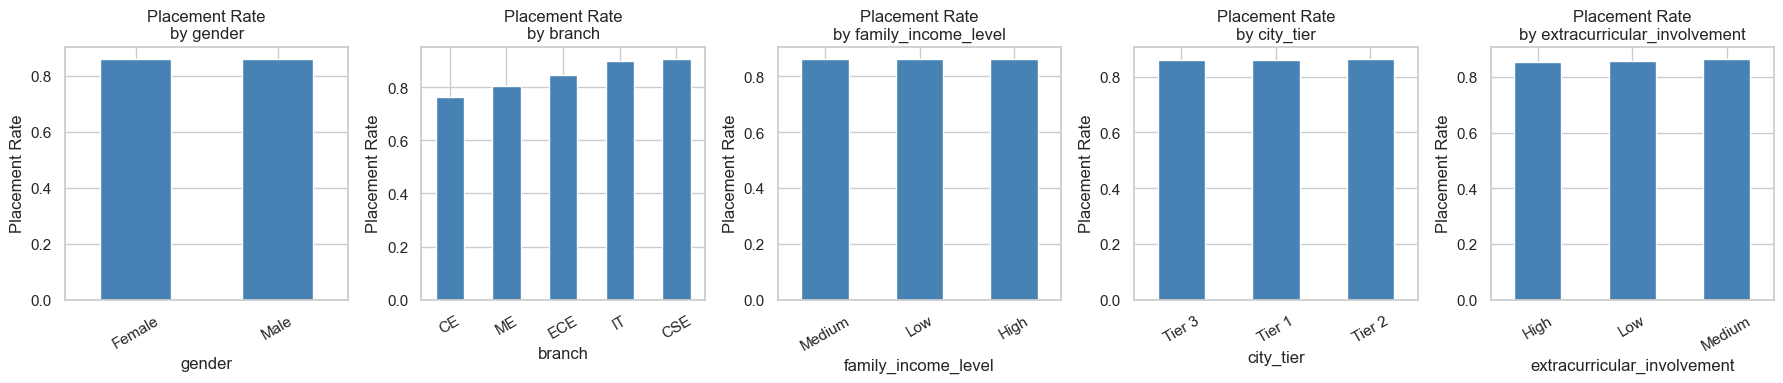

In [ ]:
cat_cols = ['gender', 'branch', 'family_income_level', 'city_tier', 'extracurricular_involvement']
fig, axes = plt.subplots(1, len(cat_cols), figsize=(18, 4))

for ax, col in zip(axes, cat_cols):
    df.groupby(col)['placement_status'].apply(
        lambda x: (x == 'Placed').mean()
    ).sort_values().plot(kind='bar', ax=ax, color='steelblue')
    ax.set_title(f'Placement Rate\nby {col}')
    ax.set_ylabel('Placement Rate')
    ax.tick_params(axis='x', rotation=30)

## 4. Feature Engineering

`CAT_COLS` and `NUM_COLS` are defined to match `train.py` exactly. Each model Pipeline runs the same `ColumnTransformer`: StandardScaler for numerical columns, OneHotEncoder for categorical ones We skip ordinal encoding because categories like `branch` or `gender` have no natural ranking. The classification target gets a separate LabelEncoder.
Keeping preprocessing inside each Pipeline means the notebook comparisons map directly to what gets deployed, with no leakage or mismatch.

In [ ]:
# Column definitions — kept in sync with data_ingestion.py / train.py
CAT_COLS = [
    'gender', 'branch', 'part_time_job', 'family_income_level',
    'city_tier', 'internet_access', 'extracurricular_involvement'
]
NUM_COLS = [
    'cgpa', 'tenth_percentage', 'twelfth_percentage', 'backlogs',
    'study_hours_per_day', 'attendance_percentage', 'projects_completed',
    'internships_completed', 'coding_skill_rating', 'communication_skill_rating',
    'aptitude_skill_rating', 'hackathons_participated', 'certifications_count',
    'sleep_hours', 'stress_level'
]

# Shared preprocessor — mirrors train.py's build_preprocessor()
def build_preprocessor():
    return ColumnTransformer(transformers=[
        ('num', StandardScaler(), NUM_COLS),
        ('cat', OneHotEncoder(handle_unknown='ignore', sparse_output=False), CAT_COLS)
    ])

# Encode classification target only
le_target = LabelEncoder()
df['placement_status_enc'] = le_target.fit_transform(df['placement_status'])
print('Target encoding ', le_target.classes_)

Target encoding — classes: ['Not Placed' 'Placed']


## 5. Train-Test Split (80:20)
80/20 split, stratified on `placement_status`. Without stratification, random chance could dump most of the minority class (Not Placed) into one set and skew the evaluation.

In [13]:
X      = df.drop(columns=['placement_status', 'placement_status_enc', 'salary_lpa'])
y_clf  = df['placement_status_enc']
y_reg  = df['salary_lpa']

X_train, X_test, yc_train, yc_test, yr_train, yr_test = train_test_split(
    X, y_clf, y_reg, test_size=0.2, random_state=42, stratify=y_clf
)

print(f'Train: {X_train.shape}, Test: {X_test.shape}')
print(f'Train placement balance:\n{yc_train.value_counts()}')

Train: (4000, 22), Test: (1000, 22)
Train placement balance:
placement_status_enc
1    3442
0     558
Name: count, dtype: int64


## 6. Classification Models

Five classifiers, all in Pipelines with the shared preprocessor. We compare on weighted F1.
Logistic Regression and KNN both need scaling since they are sensitive to feature magnitude. StandardScaler handles that. Decision Tree and Random Forest technically do not require it, but running them through the preprocessor does not hurt. XGBoost is gradient boosting and tends to be competitive on structured tabular data without much tuning.

In [14]:
clf_models = {
    'Logistic Regression': Pipeline([
        ('preprocessor', build_preprocessor()),
        ('clf', LogisticRegression(max_iter=500, random_state=42))
    ]),
    'KNN': Pipeline([
        ('preprocessor', build_preprocessor()),
        ('clf', KNeighborsClassifier())
    ]),
    'Decision Tree': Pipeline([
        ('preprocessor', build_preprocessor()),
        ('clf', DecisionTreeClassifier(random_state=42))
    ]),
    'Random Forest': Pipeline([
        ('preprocessor', build_preprocessor()),
        ('clf', RandomForestClassifier(n_estimators=100, random_state=42))
    ]),
    'XGBoost': Pipeline([
        ('preprocessor', build_preprocessor()),
        ('clf', XGBClassifier(n_estimators=100, random_state=42, eval_metric='logloss'))
    ])
}

clf_results = {}
for name, model in clf_models.items():
    model.fit(X_train, yc_train)
    preds = model.predict(X_test)
    f1 = f1_score(yc_test, preds, average='weighted')
    clf_results[name] = {'model': model, 'f1': f1, 'preds': preds}
    print(f'\n{"="*40}')
    print(f'{name} — F1 (weighted): {f1:.4f}')
    print(classification_report(yc_test, preds, target_names=le_target.classes_))



Logistic Regression — F1 (weighted): 0.8828
              precision    recall  f1-score   support

  Not Placed       0.65      0.46      0.54       139
      Placed       0.92      0.96      0.94       861

    accuracy                           0.89      1000
   macro avg       0.78      0.71      0.74      1000
weighted avg       0.88      0.89      0.88      1000


KNN — F1 (weighted): 0.8521
              precision    recall  f1-score   support

  Not Placed       0.54      0.31      0.39       139
      Placed       0.90      0.96      0.93       861

    accuracy                           0.87      1000
   macro avg       0.72      0.63      0.66      1000
weighted avg       0.85      0.87      0.85      1000


Decision Tree — F1 (weighted): 0.8459
              precision    recall  f1-score   support

  Not Placed       0.45      0.41      0.43       139
      Placed       0.91      0.92      0.91       861

    accuracy                           0.85      1000
   macro avg   

Best Classifier: Logistic Regression (F1=0.8828)


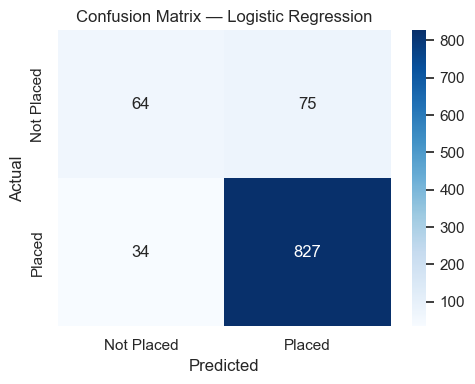

In [15]:
# Confusion matrix for best classifier
best_clf_name = max(clf_results, key=lambda k: clf_results[k]['f1'])
print(f'Best Classifier: {best_clf_name} (F1={clf_results[best_clf_name]["f1"]:.4f})')

cm = confusion_matrix(yc_test, clf_results[best_clf_name]['preds'])
plt.figure(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=le_target.classes_, yticklabels=le_target.classes_)
plt.title(f'Confusion Matrix — {best_clf_name}')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.tight_layout()
plt.show()

## 7. Regression Models
Same setup for regression: five models in Pipelines, compared on RMSE (primary) and R² (to see how much variance each model explains).
Linear Regression and KNN need scaling; the rest do not. Decision Tree is fully non-linear but prone to overfitting without pruning. Random Forest reduces that variance by averaging many trees. XGBoost builds sequentially on residuals, which tends to handle messy real-world targets like salary well.


In [16]:
reg_models = {
    'Linear Regression': Pipeline([
        ('preprocessor', build_preprocessor()),
        ('reg', LinearRegression())
    ]),
    'KNN': Pipeline([
        ('preprocessor', build_preprocessor()),
        ('reg', KNeighborsRegressor())
    ]),
    'Decision Tree': Pipeline([
        ('preprocessor', build_preprocessor()),
        ('reg', DecisionTreeRegressor(random_state=42))
    ]),
    'Random Forest': Pipeline([
        ('preprocessor', build_preprocessor()),
        ('reg', RandomForestRegressor(n_estimators=100, random_state=42))
    ]),
    'XGBoost': Pipeline([
        ('preprocessor', build_preprocessor()),
        ('reg', XGBRegressor(n_estimators=100, random_state=42))
    ])
}

reg_results = {}
for name, model in reg_models.items():
    model.fit(X_train, yr_train)
    preds = model.predict(X_test)
    rmse = np.sqrt(mean_squared_error(yr_test, preds))
    r2   = r2_score(yr_test, preds)
    mae  = mean_absolute_error(yr_test, preds)
    reg_results[name] = {'model': model, 'rmse': rmse, 'r2': r2, 'mae': mae, 'preds': preds}
    print(f'{name:25s} — RMSE: {rmse:.4f} | R²: {r2:.4f} | MAE: {mae:.4f}')


Linear Regression         — RMSE: 3.9948 | R²: 0.5877 | MAE: 2.8387
KNN                       — RMSE: 4.5478 | R²: 0.4657 | MAE: 2.9609
Decision Tree             — RMSE: 5.4875 | R²: 0.2221 | MAE: 3.1731
Random Forest             — RMSE: 4.0750 | R²: 0.5710 | MAE: 2.7065
XGBoost                   — RMSE: 4.2244 | R²: 0.5390 | MAE: 2.7749


Best Regressor: Linear Regression (RMSE=3.9948)


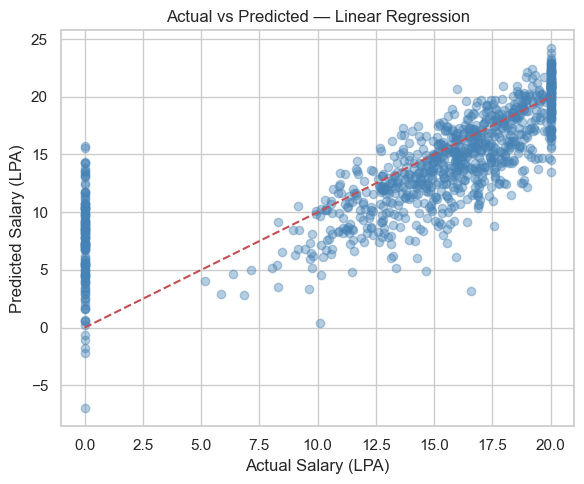

In [ ]:
# Actual vs Predicted for best regressor
best_reg_name = min(reg_results, key=lambda k: reg_results[k]['rmse'])
print(f'Best Regressor: {best_reg_name} (RMSE={reg_results[best_reg_name]["rmse"]:.4f})')

best_reg_preds = reg_results[best_reg_name]['preds']
plt.figure(figsize=(6, 5))
plt.scatter(yr_test, best_reg_preds, alpha=0.4, color='steelblue')
plt.plot([yr_test.min(), yr_test.max()], [yr_test.min(), yr_test.max()], 'r--')
plt.xlabel('Actual Salary (LPA)')
plt.ylabel('Predicted Salary (LPA)')
plt.title(f'Actual vs Predicted — {best_reg_name}')
plt.tight_layout()
plt.show()


## 8. Model Selection Summary

Weighted F1 was chosen over accuracy because accuracy lies with an 86/14 class split. A model that always guesses "Placed" still hits 86%. F1 accounts for false positives and false negatives across both classes.

Logistic Regression came out on top (F1 = 0.8828), slightly ahead of Random Forest (0.8662) and XGBoost (0.8656). The gap is small, but it suggests the features are mostly linearly separable once scaled. The simpler model wins because the problem doesn't need more complexity.

For regression, RMSE is the primary metric and R² tells us how much salary variance is actually explained. Linear Regression wins here too (RMSE = 3.9948, R² = 0.5877).

An R² of 0.59 means roughly 41% of salary variance is unaccounted for. That's expected. Salary is heavily influenced by things this dataset doesn't have: offer negotiation, company size, city-level cost differences. Linear Regression beating Random Forest suggests the underlying relationship is roughly linear with these features, so extra complexity doesn't pay off.

All five models in both tasks use the same ColumnTransformer (StandardScaler + OneHotEncoder) as train.py, so the winners above are what gets deployed.

From the correlation heatmap, the clearest predictors are `cgpa`(strongest individual signal for both placement and salary), `coding_skill_rating` and `aptitude_skill_rating` (both correlate strongly with placement outcomes), `internships_completed` (adds real signal beyond academic metrics), and `backlogs` (consistently negative, shows up in both tasks).

In [18]:
print('FINAL MODEL COMPARISON')
print('\nClassification (higher F1 = better):')
for name, r in sorted(clf_results.items(), key=lambda x: -x[1]['f1']):
    print(f'  {name:25s}: F1 = {r["f1"]:.4f}')

print('\nRegression (lower RMSE = better):')
for name, r in sorted(reg_results.items(), key=lambda x: x[1]['rmse']):
    print(f'  {name:25s}: RMSE = {r["rmse"]:.4f} | R² = {r["r2"]:.4f}')

print(f'\nBest Classifier : {best_clf_name}')
print(f'Best Regressor  : {best_reg_name}')

FINAL MODEL COMPARISON

Classification (higher F1 = better):
  Logistic Regression      : F1 = 0.8828
  Random Forest            : F1 = 0.8662
  XGBoost                  : F1 = 0.8656
  KNN                      : F1 = 0.8521
  Decision Tree            : F1 = 0.8459

Regression (lower RMSE = better):
  Linear Regression        : RMSE = 3.9948 | R² = 0.5877
  Random Forest            : RMSE = 4.0750 | R² = 0.5710
  XGBoost                  : RMSE = 4.2244 | R² = 0.5390
  KNN                      : RMSE = 4.5478 | R² = 0.4657
  Decision Tree            : RMSE = 5.4875 | R² = 0.2221

Best Classifier : Logistic Regression
Best Regressor  : Linear Regression
